In [7]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()


1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


---
## Average all the spectrum.

100%|██████████| 43042/43042 [00:09<00:00, 4396.07it/s]


Spectrum index 102 has invalid normalization factor. Skipping.


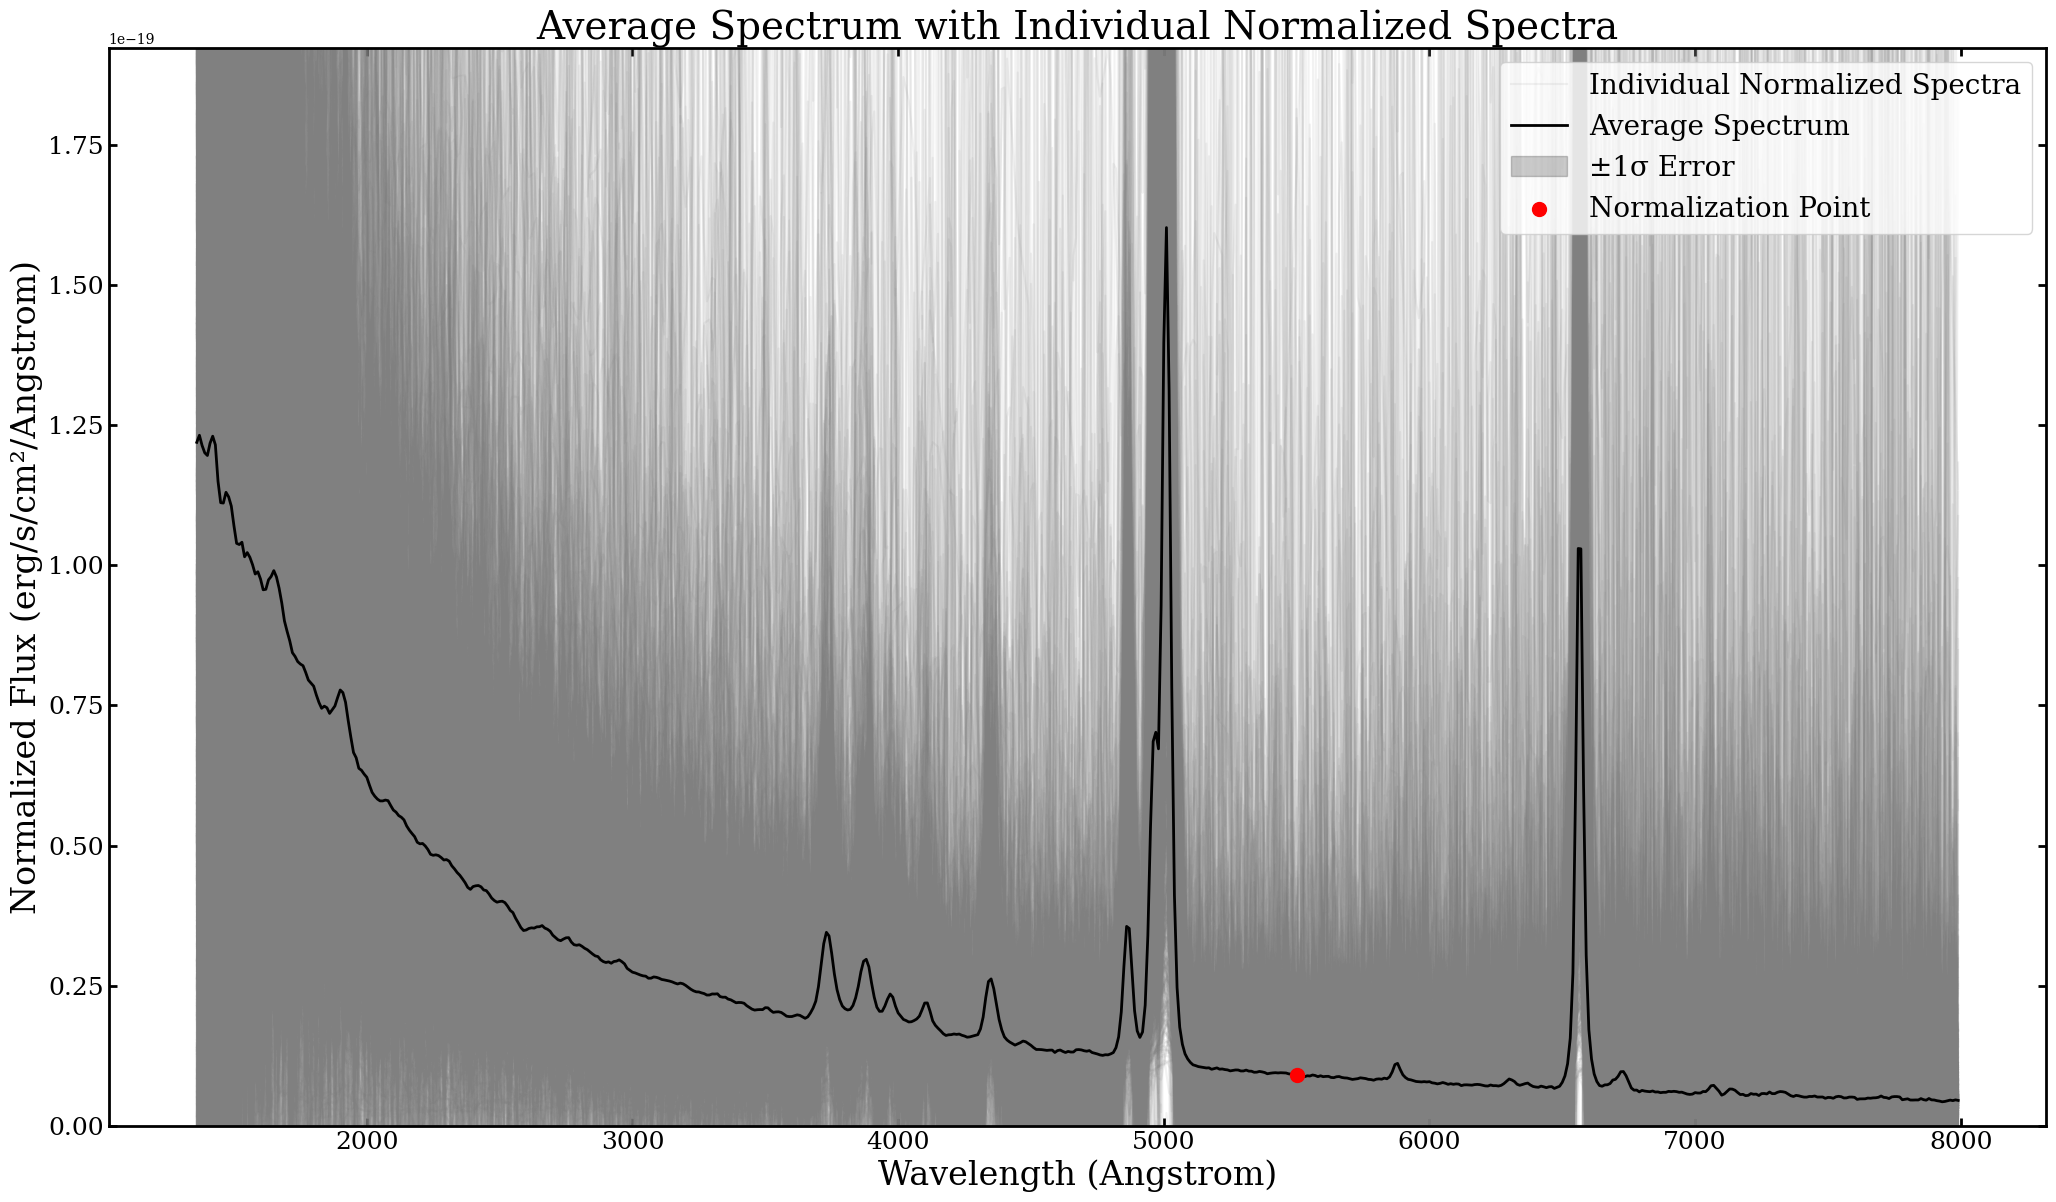

In [3]:
averager=FL.SpectrumAverager()
for surveyid_subid, catalog in tqdm(DJAv4Catalog.catalog_iterator(), total=len(DJAv4Catalog.catalog)):
    if not catalog['sample_flag']:
        continue

    averager.load_spectrum_catalog([surveyid_subid],DJAv4Catalog)

averager.create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
averager.interpolate_spectra(interpolation_method='linear')
averager.spectrum_normalization_within_range(wavelength_range=(5250,5750))
averager.compute_average_spectrum(method='mean', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
fig,ax=averager.plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.1, show_normalization_point=True, reference_wavelength=5500.0,if_show=False)

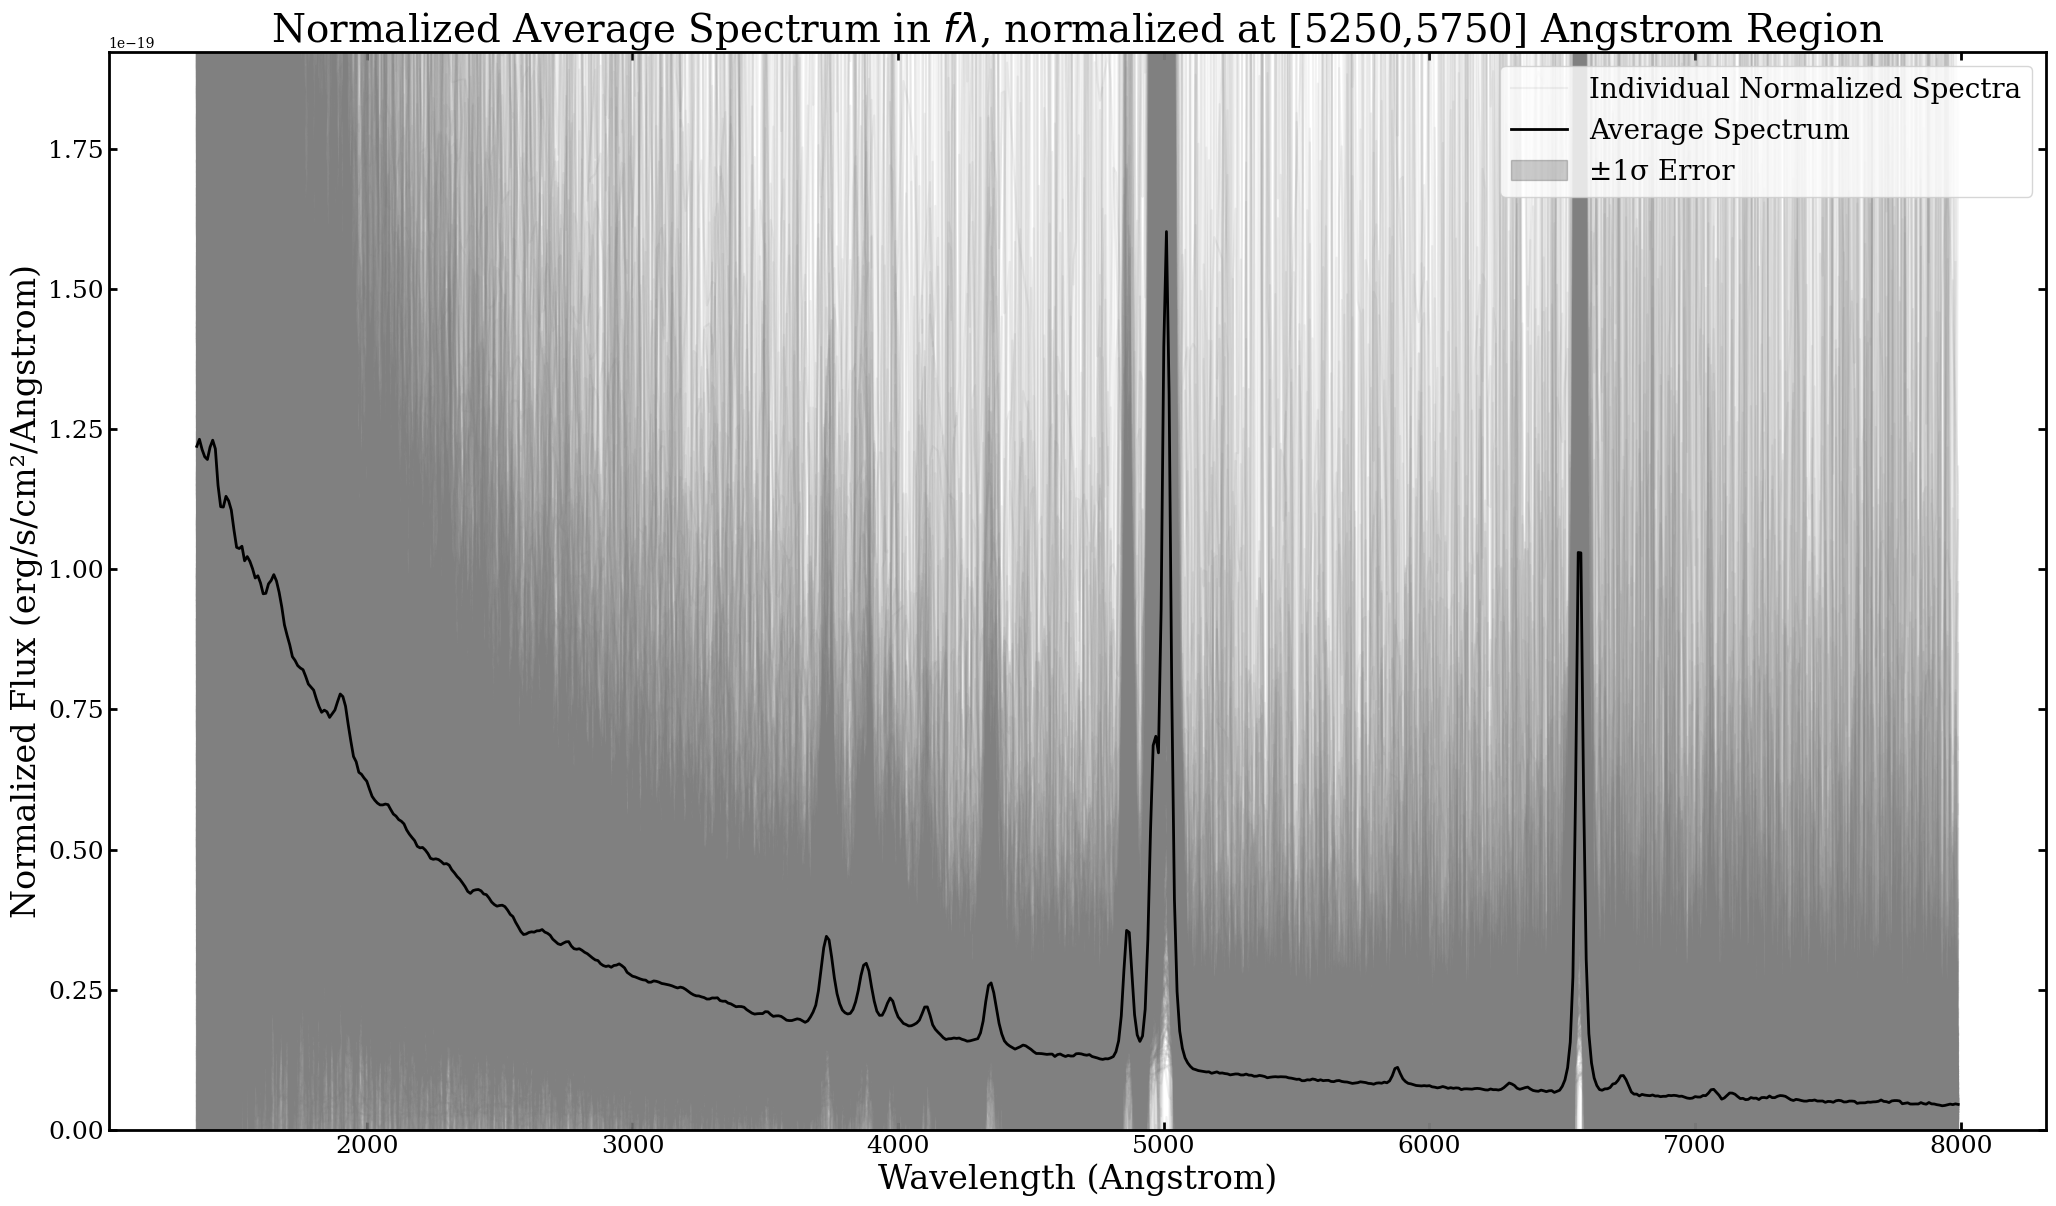

In [4]:
fig,ax=averager.plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.1, show_normalization_point=False, reference_wavelength=5500.0,if_show=False)
ax.set_title('Normalized Average Spectrum in $f\\lambda$, normalized at [5250,5750] Angstrom Region', fontsize=28)
plt.savefig('Region_Normalized_Average_Spectrum_f_lambda.pdf', bbox_inches='tight', dpi=300)

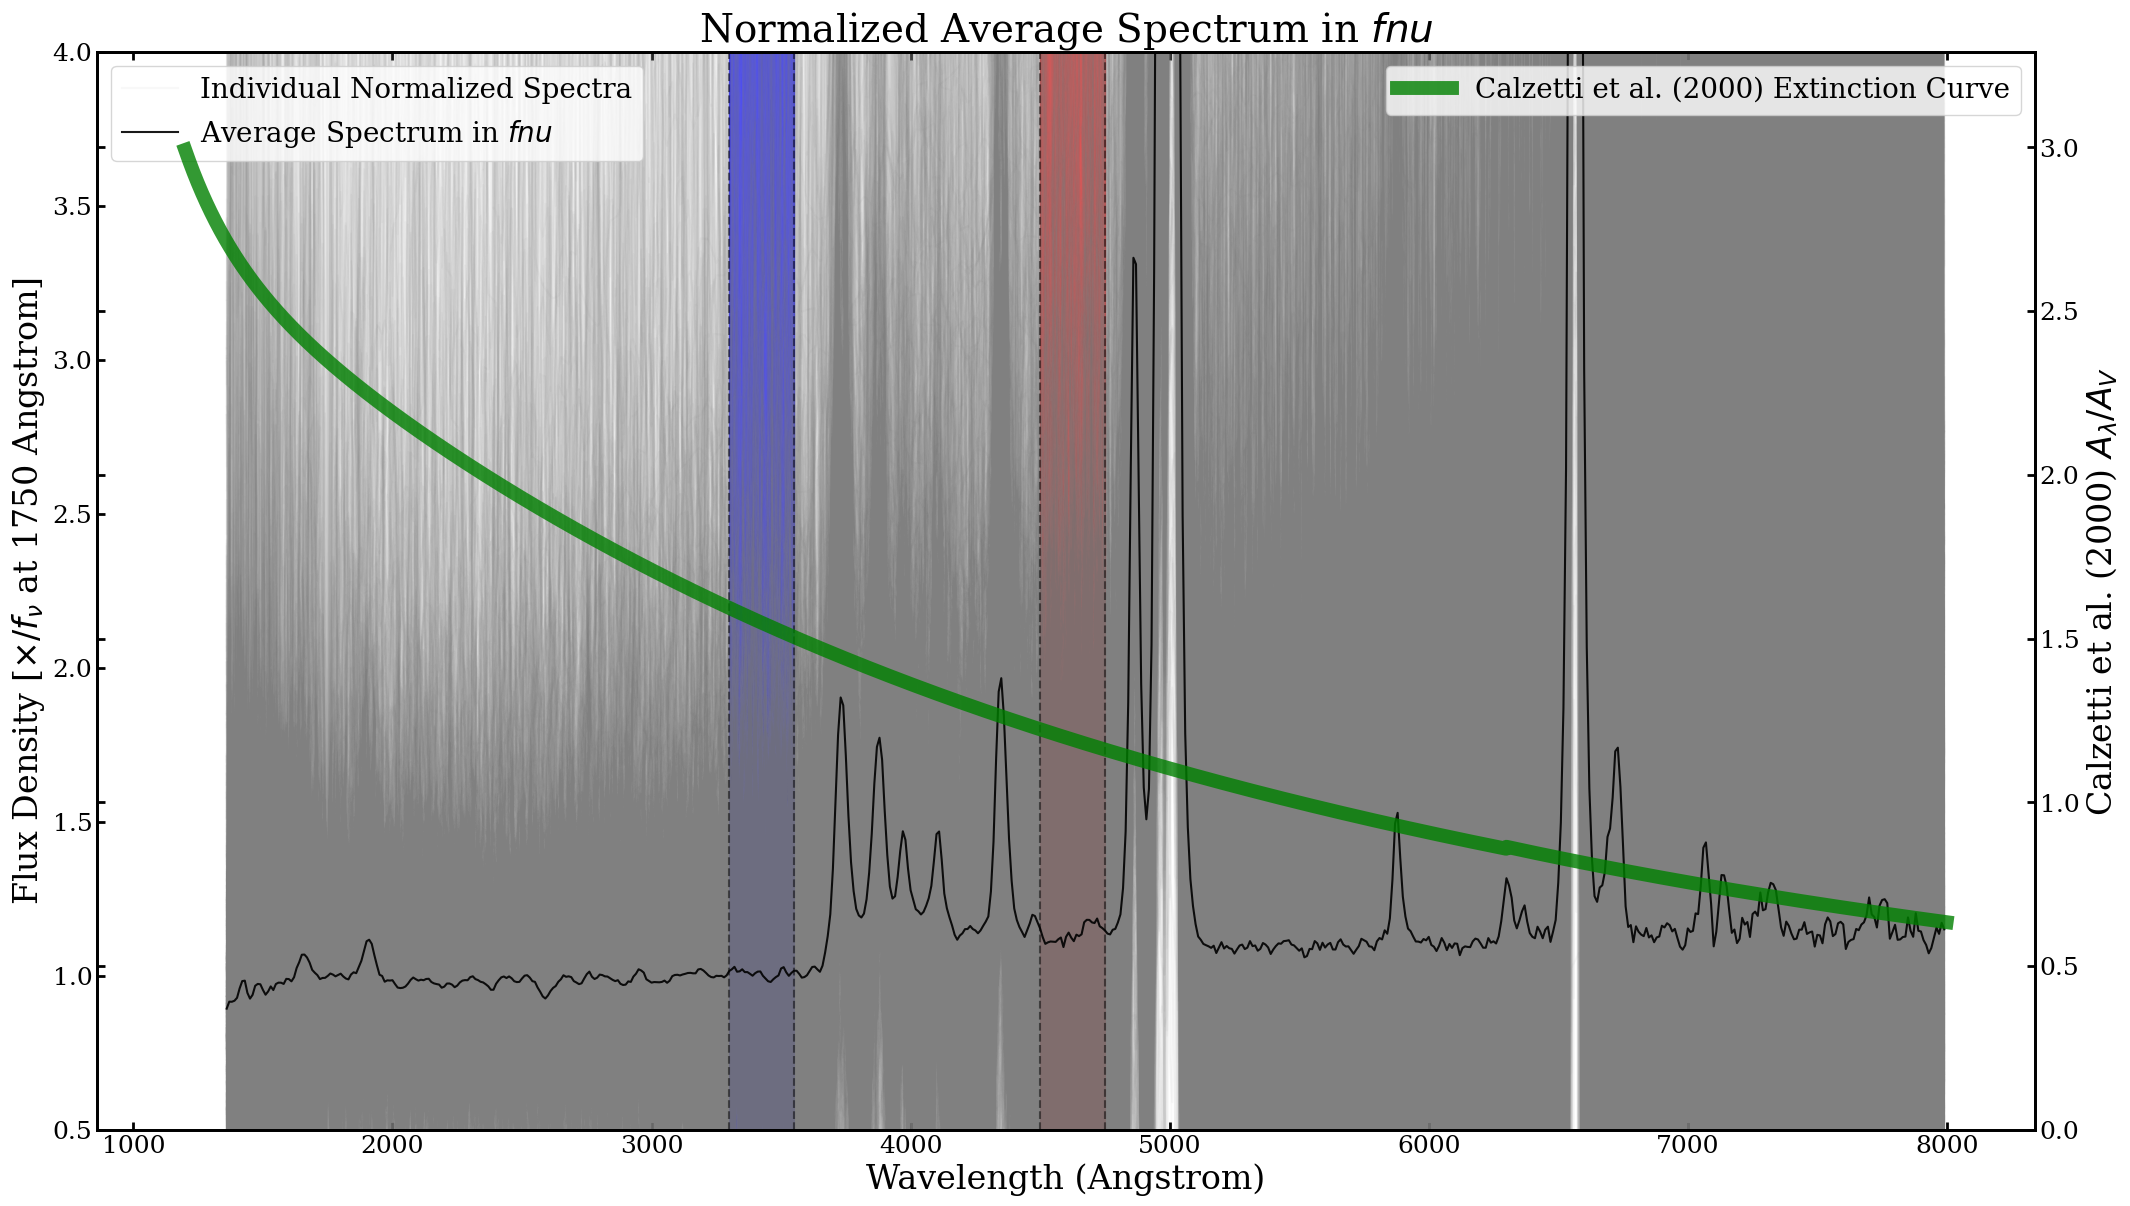

In [ ]:
fig, ax = plt.subplots(figsize=(25,14))

for normalized_flux in averager.normalized_fluxes:
    f_nu=normalized_flux*u.erg/u.s/u.cm**2/u.AA
    f_nu=f_nu.to(u.Jy, equivalencies=u.spectral_density(averager.common_wavelength*u.AA))
    f_nu_1750=f_nu[np.abs(averager.common_wavelength-1750).argmin()]
    f_nu=f_nu.value/f_nu_1750.value
    ax.plot(averager.common_wavelength, f_nu, color='gray', alpha=0.05, label='Individual Normalized Spectra' if 'Individual Normalized Spectra' not in ax.get_legend_handles_labels()[1] else "")

wavelength=averager.common_wavelength*u.AA
flux=averager.average_flux*u.erg/u.s/u.cm**2/u.AA
f_nu=flux.to(u.Jy, equivalencies=u.spectral_density(wavelength))
f_nu_1750=f_nu[np.abs(wavelength.value-1750).argmin()]
f_nu=f_nu.value/f_nu_1750.value
ax.plot(wavelength, f_nu, color='black', alpha=0.9, label='Average Spectrum in $fnu$')

ax.set_xlabel('Wavelength (Angstrom)', fontsize=24)
ax.set_ylabel(r'Flux Density [$\times / f_\nu$ at 1750 Angstrom]', fontsize=24)
ax.legend(fontsize=20,loc='best')
ax.set_title('Normalized Average Spectrum in $fnu$', fontsize=28)
ax.set_ylim(0.5,4)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.axvline(4750, color='k', linestyle='--', alpha=0.5)
ax.axvline(4500, color='k', linestyle='--', alpha=0.5)
ax.fill_betweenx([0,4], 4500, 4750, color='red', alpha=0.7)
ax.axvline(3300, color='k', linestyle='--', alpha=0.5)
ax.axvline(3550, color='k', linestyle='--', alpha=0.5)
ax.fill_betweenx([0,4], 3300, 3550, color='blue', alpha=0.7)


twinx=ax.twinx()
twinx.set_ylabel(r'Calzetti et al. (2000) $A_\lambda / A_V$', fontsize=24)
calzetti_wavelengths = np.arange(1200, 8000, 1)  # Angstrom
calzetti_wavelengths_um = calzetti_wavelengths / 1e4

k_lambda = np.piecewise(calzetti_wavelengths_um,
    [calzetti_wavelengths_um < 0.63,
     (calzetti_wavelengths_um >= 0.63) & (calzetti_wavelengths_um <= 2.20)],
    [lambda x: 2.659 * (-2.156 + 1.509 / x - 0.198 / (x**2) + 0.011 / (x**3)) + 4.05,
     lambda x: 2.659 * (-1.857 + 1.040 / x) + 4.05]
)
A_lambda_over_A_V = k_lambda / 4.05
twinx.plot(calzetti_wavelengths, A_lambda_over_A_V, color='green', linestyle='-',linewidth=10, alpha=0.8, label='Calzetti et al. (2000) Extinction Curve')
twinx.set_ylim(0, np.max(A_lambda_over_A_V)*1.1)
twinx.spines['bottom'].set_linewidth(2)
twinx.spines['top'].set_linewidth(2)
twinx.spines['left'].set_linewidth(2)
twinx.spines['right'].set_linewidth(2)
twinx.spines['bottom'].set_color('black')
twinx.spines['top'].set_color('black')
twinx.spines['left'].set_color('black')
twinx.spines['right'].set_color('black')
twinx.yaxis.set_ticks_position('both')
twinx.xaxis.set_ticks_position('both')
twinx.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
twinx.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
twinx.xaxis.set_tick_params(length=6, which='major')
twinx.xaxis.set_tick_params(length=3, which='minor')
twinx.yaxis.set_tick_params(length=6, which='major')
twinx.yaxis.set_tick_params(length=3, which='minor')
twinx.legend(fontsize=20, loc='upper right')





plt.savefig('Normalized_Average_Spectrum_fnu_Calzetti2000_Extinction_Curve.pdf', bbox_inches='tight', dpi=300)


plt.show()

---
## Binning the spectrum and average different attenuation spectrum.

In [11]:

group_conditions = [(-0.2,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

In [12]:
group0_averager=FL.SpectrumAverager()
group1_averager=FL.SpectrumAverager()
group2_averager=FL.SpectrumAverager()
group3_averager=FL.SpectrumAverager()
group4_averager=FL.SpectrumAverager()
group5_averager=FL.SpectrumAverager()
group6_averager=FL.SpectrumAverager()


for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
    halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
    hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
    balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
    group_index=group_condition_func(balmer_decrement)
    if group_index==-1:
        continue

    averager_to_use='group'+str(group_index)+'_averager'
    globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)




In [13]:
for i in range(7):
    averager_to_use='group'+str(i)+'_averager'
    globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
    globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
    globals()[averager_to_use].spectrum_normalization_within_range(wavelength_range=(5250,5750),target_flux=1.e-19)
    globals()[averager_to_use].compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=16, upper_percentile=84)
    # globals()[averager_to_use].plot_average_spectrum(show_individual=True, show_average=True, show_error=True, figsize=(25,14), alpha=0.3, show_normalization_point=True, reference_wavelength=5500.0,ylim=(0,2e-18))

Spectrum index 20 has invalid normalization factor. Skipping.


In [ ]:
def power_law(x, amplitude, exponent):
    """
    Power law function for fitting.
    """
    return amplitude * (x ** exponent)

def fit_power_law(restframe_wave, restframe_flux_lambda, initial_guess=(1e-19, -1.0)):
    """
    Fit a power law to the given wavelengths and fluxes.
    """

    fit_mask = (restframe_wave.data >= 1407) & (restframe_wave.data <= 2580)
    wave_to_fit = restframe_wave[fit_mask].data
    flux_to_fit = restframe_flux_lambda[fit_mask].data

    # if np.any(error_to_fit <= 0):
    #     print("Warning: Non-positive error values found. These will be ignored in the fit.")
    #     valid_error_mask = error_to_fit > 0
    #     wave_to_fit = wave_to_fit[valid_error_mask]
    #     flux_to_fit = flux_to_fit[valid_error_mask]
    #     error_to_fit = error_to_fit[valid_error_mask]

    if np.any(np.isnan(flux_to_fit)) :
        print("Warning: NaN values found in flux or error arrays. These will be ignored in the fit.")
        valid_nan_mask = ~np.isnan(flux_to_fit)
        wave_to_fit = wave_to_fit[valid_nan_mask]
        flux_to_fit = flux_to_fit[valid_nan_mask]

    fit_successful = False
    if len(wave_to_fit) > 2:
        try:
            initial_guess = [np.median(flux_to_fit), -1.5]
            popt, pcov = scipy.optimize.curve_fit(
                power_law,
                xdata=wave_to_fit,
                ydata=flux_to_fit,
                p0=initial_guess,
                absolute_sigma=True,
                maxfev=500000
            )

            fit_amplitude, fit_exponent = popt
            perr = np.sqrt(np.diag(pcov))
            fit_amplitude_err, fit_exponent_err = perr
            fit_successful = True

            # print("\n--- Power-law Fit Results ---")
            # print(f"  Amplitude: {fit_amplitude:.3e} ± {fit_amplitude_err:.3e}")
            # print(f"  Exponent:  {fit_exponent:.3f} ± {fit_exponent_err:.3f}")
            # print("---------------------------\n")
            return fit_amplitude, fit_amplitude_err, fit_exponent, fit_exponent_err

        except RuntimeError as e:
            print(f"Fit failed for {surveyid_subid}: {e}")
            return None


In [62]:
decrement_list=[]
uv_list=[]
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    spectrum0=FL.Spectrum_1d(averager.common_wavelength*u.AA, 0, None, averager.average_flux*1e19*u.erg/u.s/u.cm**2/u.AA)
    alpharestFrameWavelength=6563.0*astropy.units.AA
    spectrum0.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+50.0*astropy.units.AA)
    fitting=FL.SpectralLineFitter(spectrum0, alpharestFrameWavelength)
    alpha=fitting.fit_single_gaussian_with_offset()['integrated_flux']

    alpharestFrameWavelength=4863.0*astropy.units.AA
    spectrum0.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+50.0*astropy.units.AA)
    fitting=FL.SpectralLineFitter(spectrum0, alpharestFrameWavelength)
    beta=fitting.fit_single_gaussian_with_offset()['integrated_flux']

    uv_region_wavelengths = (1407.0, 2580.0) * astropy.units.AA
    spectrum0.set_boundarys(uv_region_wavelengths[0], uv_region_wavelengths[1])
    powerlaw_params=fit_power_law(spectrum0.processing_wavelengths, spectrum0.processing_flux_lambda)
    print(powerlaw_params)

    balmer=(alpha/beta)
    decrement=np.log(balmer/2.86)
    uv=(powerlaw_params[2])
    decrement_list.append(decrement)
    uv_list.append(uv)

(np.float64(24234144.687589966), np.float64(9522263.694157852), np.float64(-1.9705361691717023), np.float64(0.05261478478227961))
(np.float64(15440688.269184327), np.float64(6483909.328576578), np.float64(-1.9196874298538438), np.float64(0.056209605867096564))
(np.float64(2565161.5065913657), np.float64(1301875.6576925102), np.float64(-1.7072351567176995), np.float64(0.06782983615140051))
(np.float64(876032.6736647992), np.float64(555874.8088697268), np.float64(-1.5946073983646778), np.float64(0.08473348584884217))
(np.float64(229286.41226141935), np.float64(211717.56425244376), np.float64(-1.4668411769591256), np.float64(0.12318413212496288))
(np.float64(112844.42132186517), np.float64(106202.57112430954), np.float64(-1.3755134255848382), np.float64(0.1254656031422141))


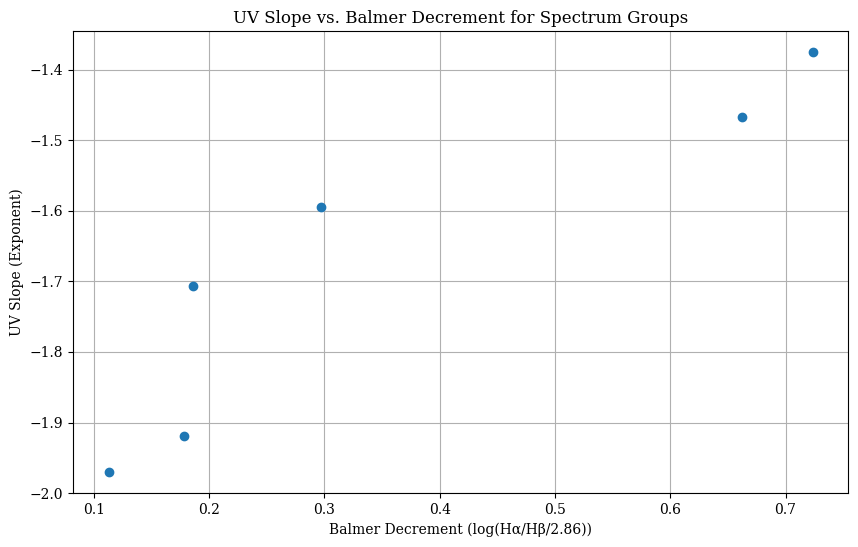

In [63]:
plt.figure(figsize=(10,6))
plt.plot(decrement_list, uv_list, marker='o', linestyle='None')
plt.xlabel('Balmer Decrement (log(Hα/Hβ/2.86))')
plt.ylabel('UV Slope (Exponent)')
plt.title('UV Slope vs. Balmer Decrement for Spectrum Groups')
plt.grid(True)
plt.show()

---
## attenuation curve

In [14]:

group_conditions = [(-0.2,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]
group_decrement_list=[]

for i in range(6):
    decrement_list=[]

    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index!=i:
            continue
        if group_index==-1:
            continue

        decrement_list.append(balmer_decrement)

    group_decrement_list.append(np.mean(decrement_list))



In [15]:
group_decrement_list

[np.float64(-0.07963317232146354),
 np.float64(0.06204199540297288),
 np.float64(0.1468996563812721),
 np.float64(0.24619297697293827),
 np.float64(0.34784501292857684),
 np.float64(0.49922688741835725)]

In [16]:
model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
tau_lambda_list=[]
Q_lambda_list=[]

for i in range(1,6):
    averager_to_use='group'+str(i)+'_averager'
    tau_lambda_list=[]
    groupi_averager=globals()[averager_to_use]
    tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
    tau_lambda_list.append(tau_lambda)
    Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
    Q_lambda_list.append(Q_lambda)

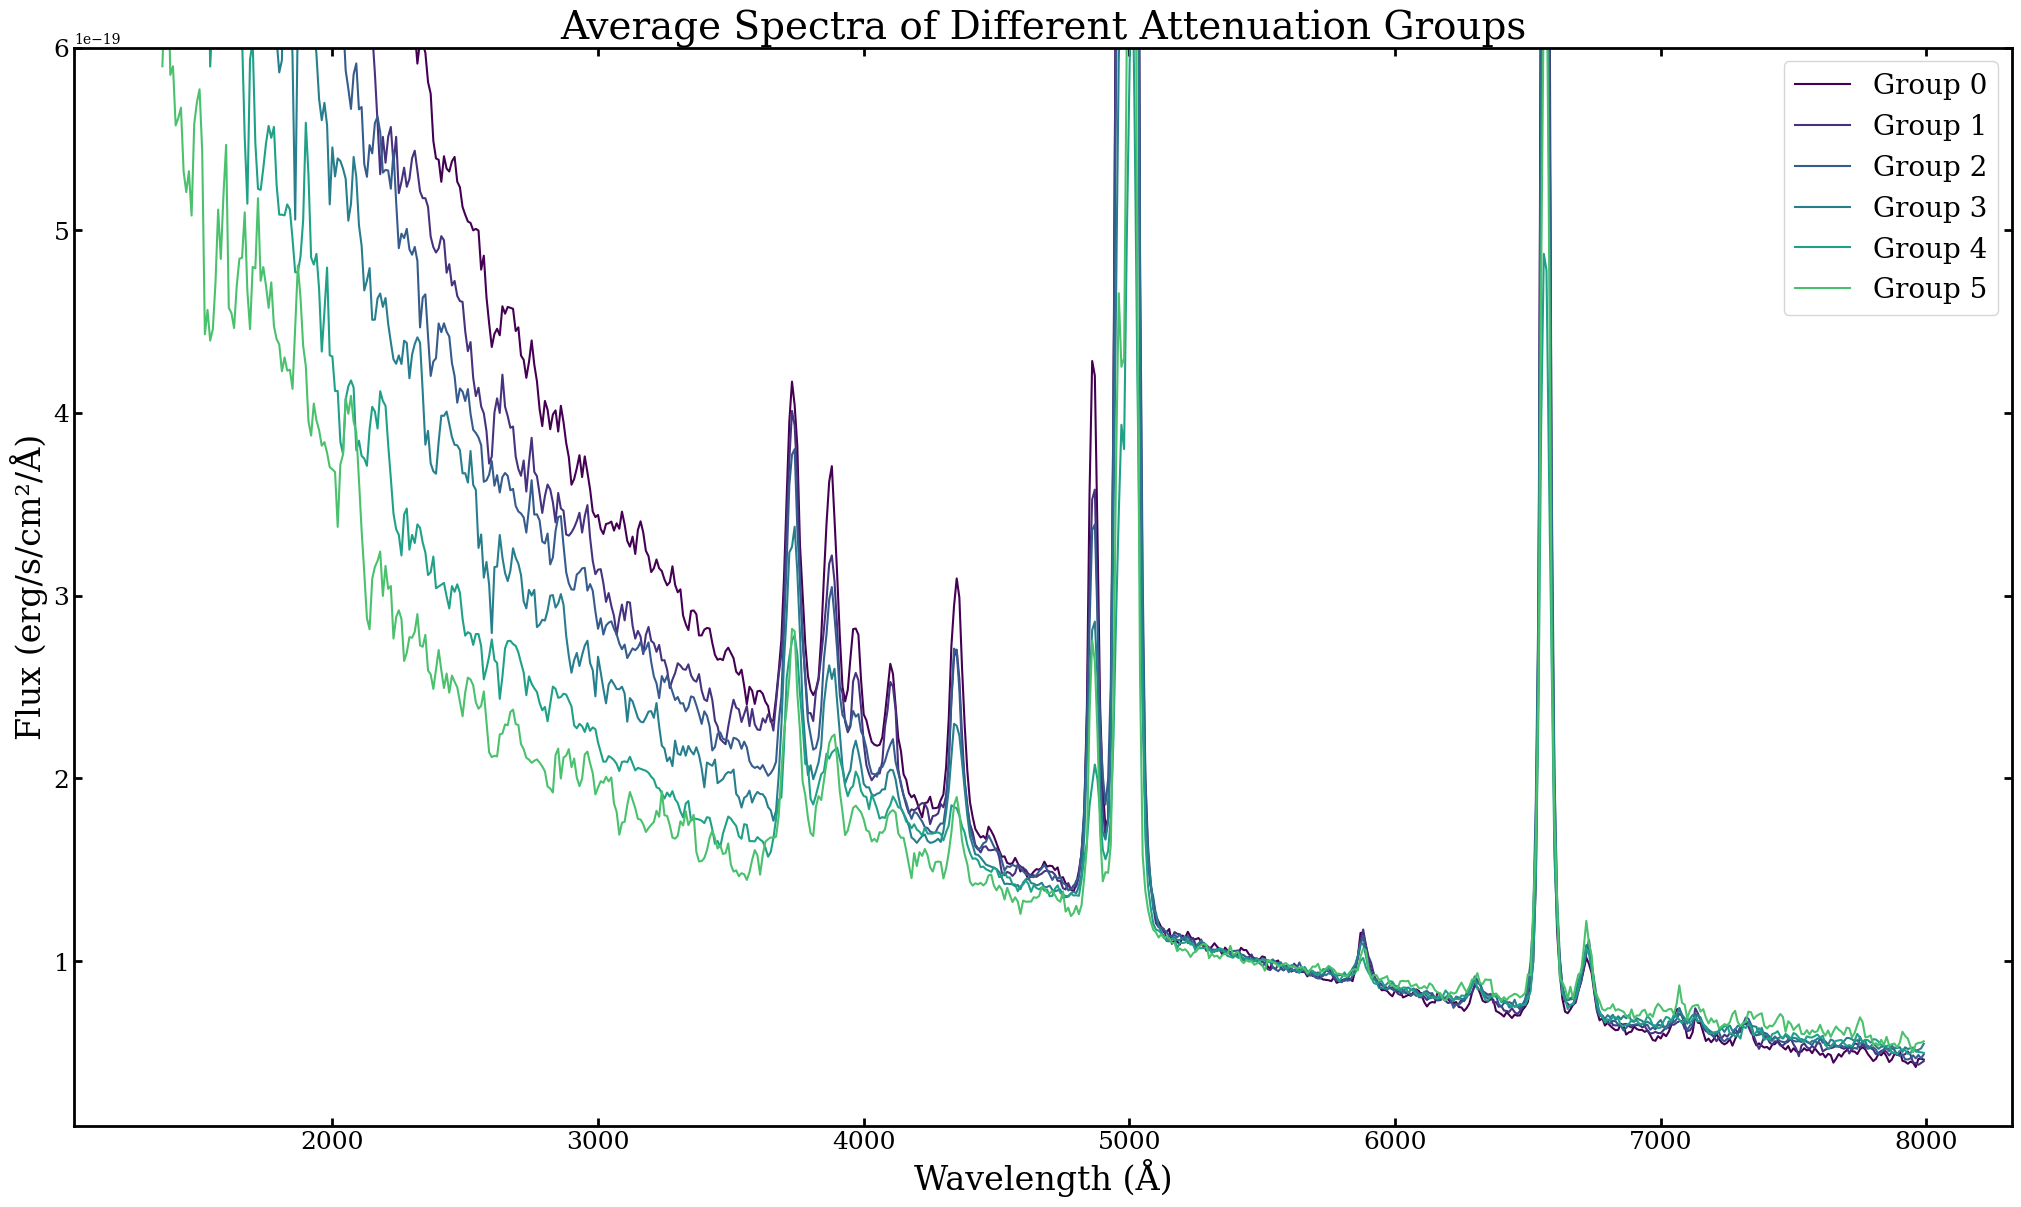

In [22]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,7))
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=24)
ax.legend(fontsize=20)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')

ax.set_title('Average Spectra of Different Attenuation Groups', fontsize=28)
ax.set_ylim(1e-20,6e-19)
plt.savefig('Average_Spectra_of_Different_Attenuation_Groups_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

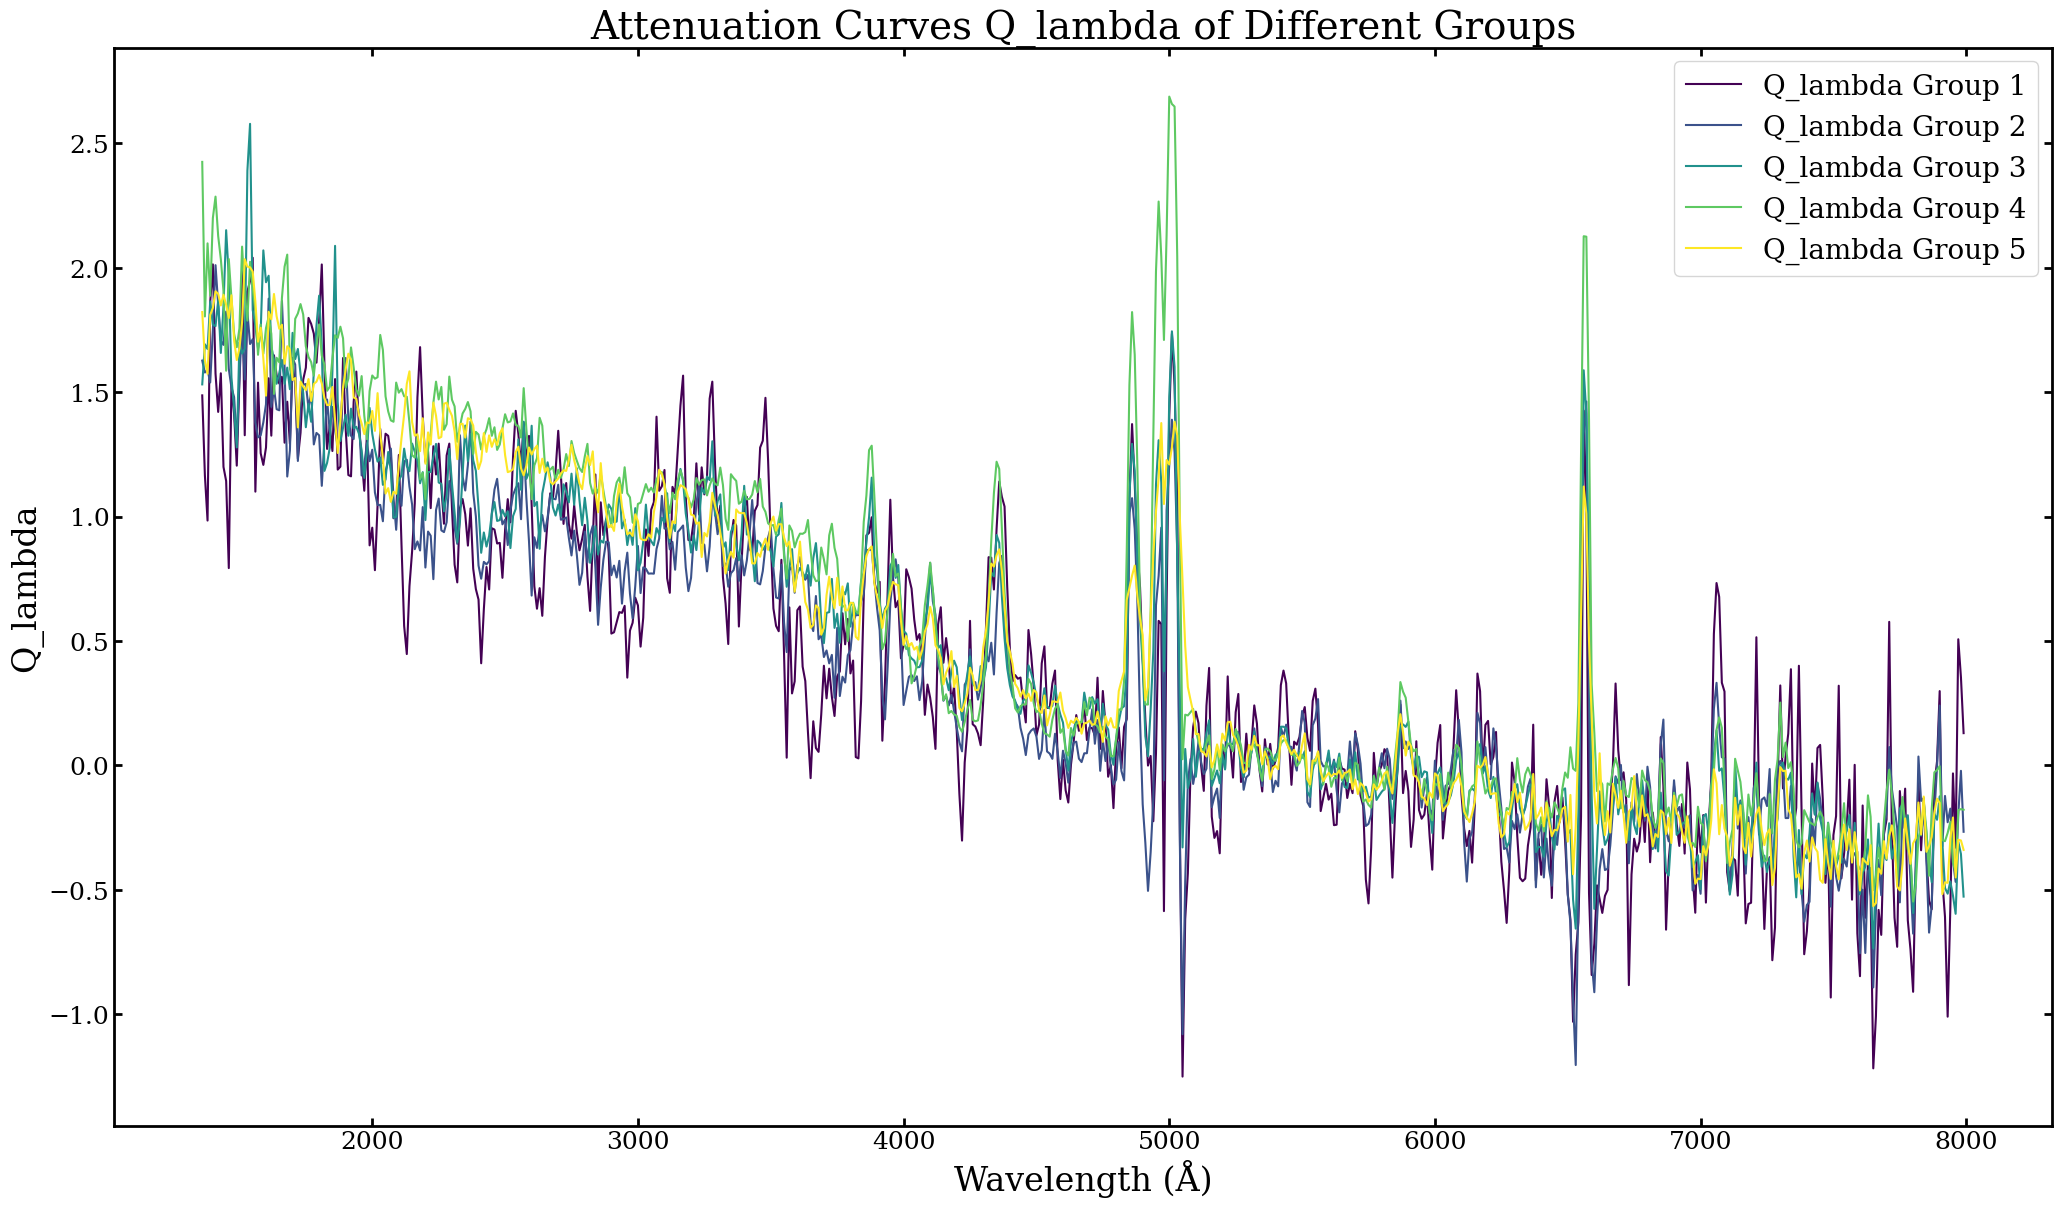

In [23]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,1,5))
for i in range(5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color=colors[i], label='Q_lambda Group '+str(i+1))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Q_lambda', fontsize=24)
ax.legend(fontsize=20)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.set_title('Attenuation Curves Q_lambda of Different Groups', fontsize=28)
plt.savefig('Attenuation_Curves_Q_lambda_of_Different_Groups_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [19]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

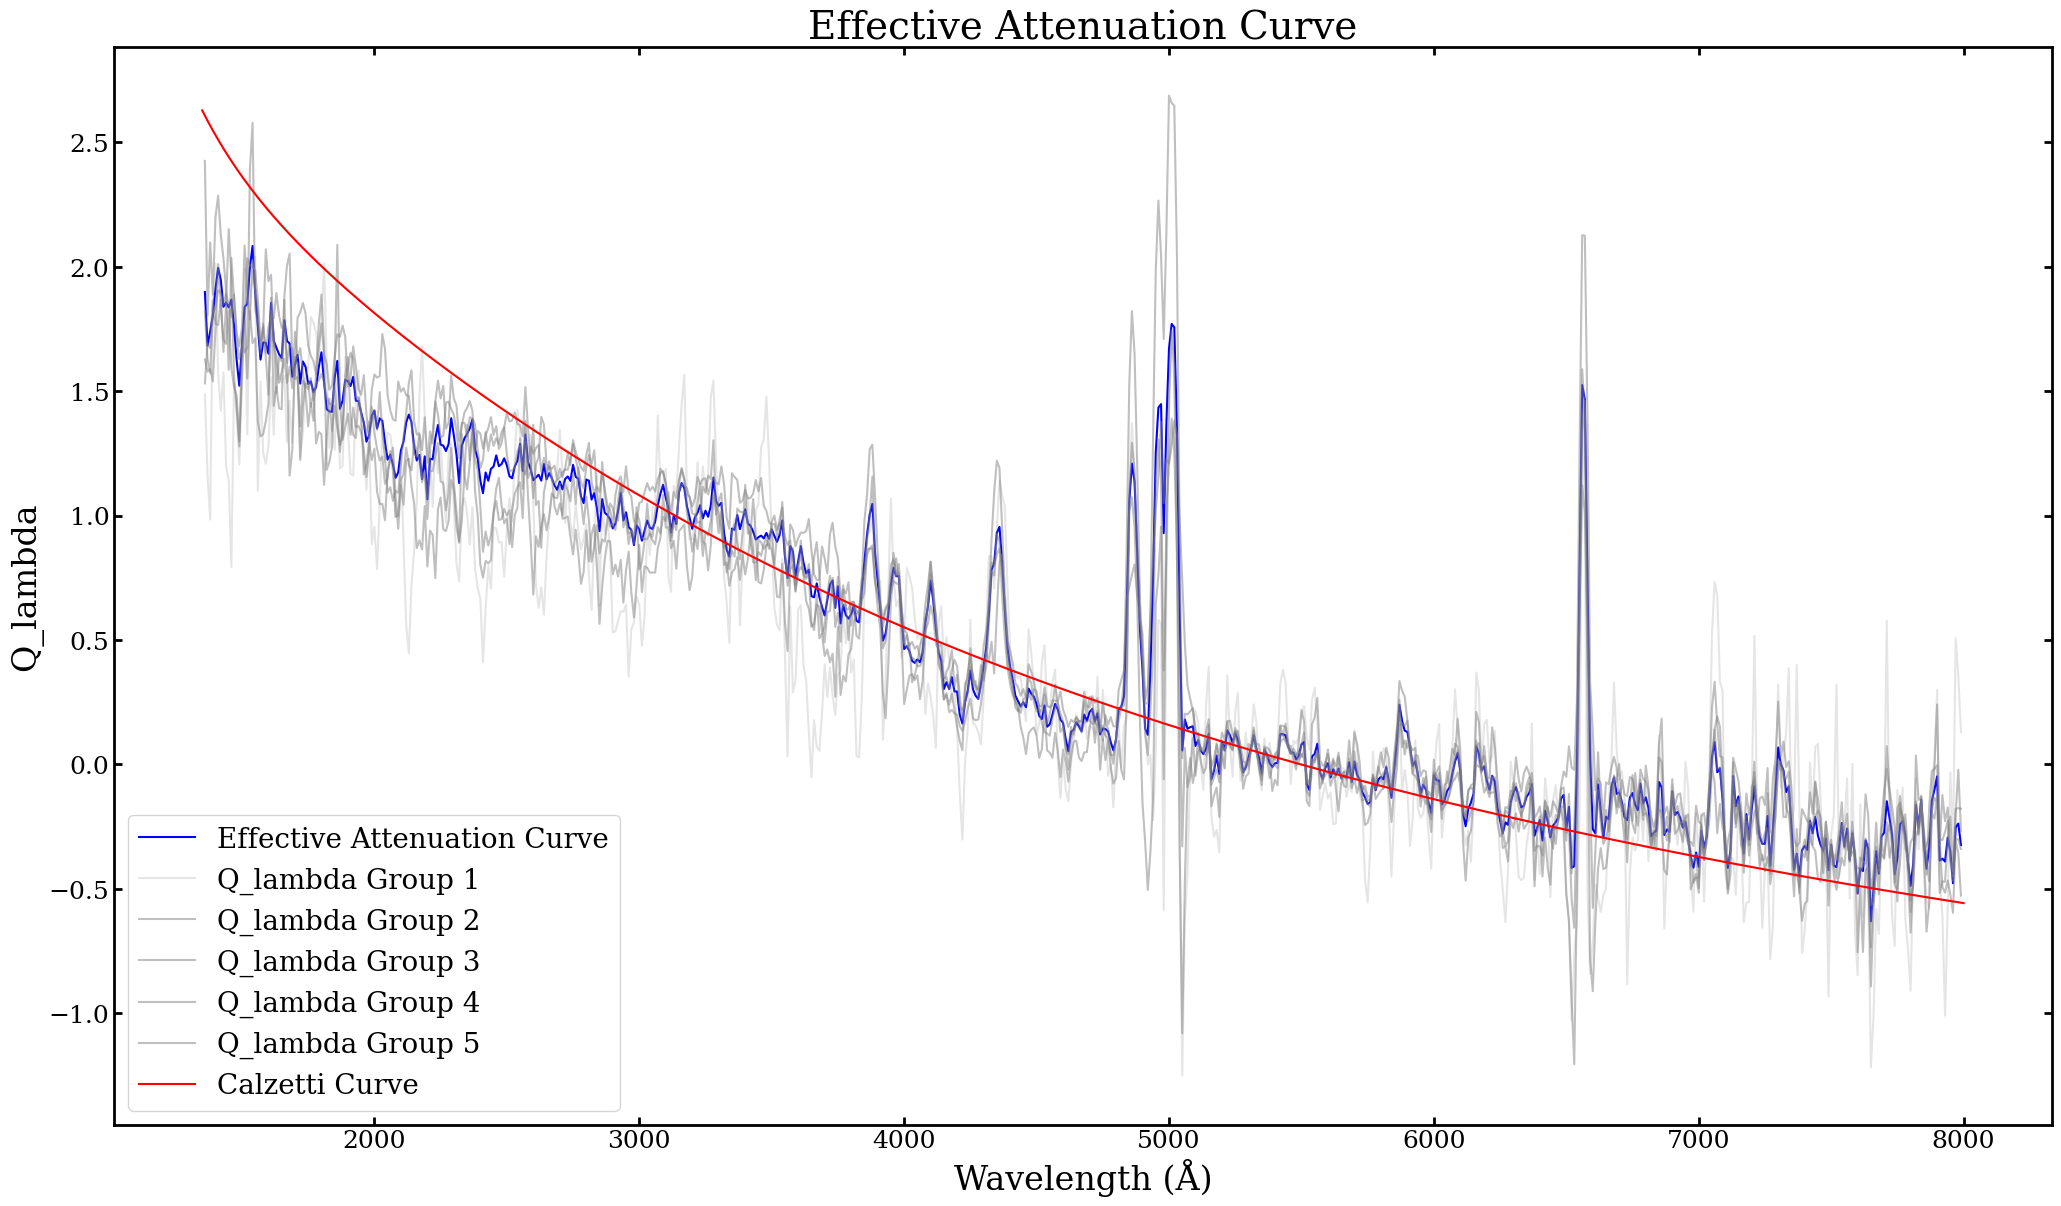

In [24]:
Q_lambda_array=np.array(Q_lambda_list)


effective_attenuation_curve=np.average(Q_lambda_array[1:], axis=0, weights=[group_decrement_list[2]-group_decrement_list[0], group_decrement_list[3]-group_decrement_list[0], group_decrement_list[4]-group_decrement_list[0], group_decrement_list[5]-group_decrement_list[0]])
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
for i in range(0,5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=24)
plt.ylabel('Q_lambda', fontsize=24)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.set_title('Effective Attenuation Curve', fontsize=28)
plt.legend(fontsize=20)
plt.savefig('Effective_Attenuation_Curve_vs_Calzetti_Curve_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

---
Compare with Calzetti

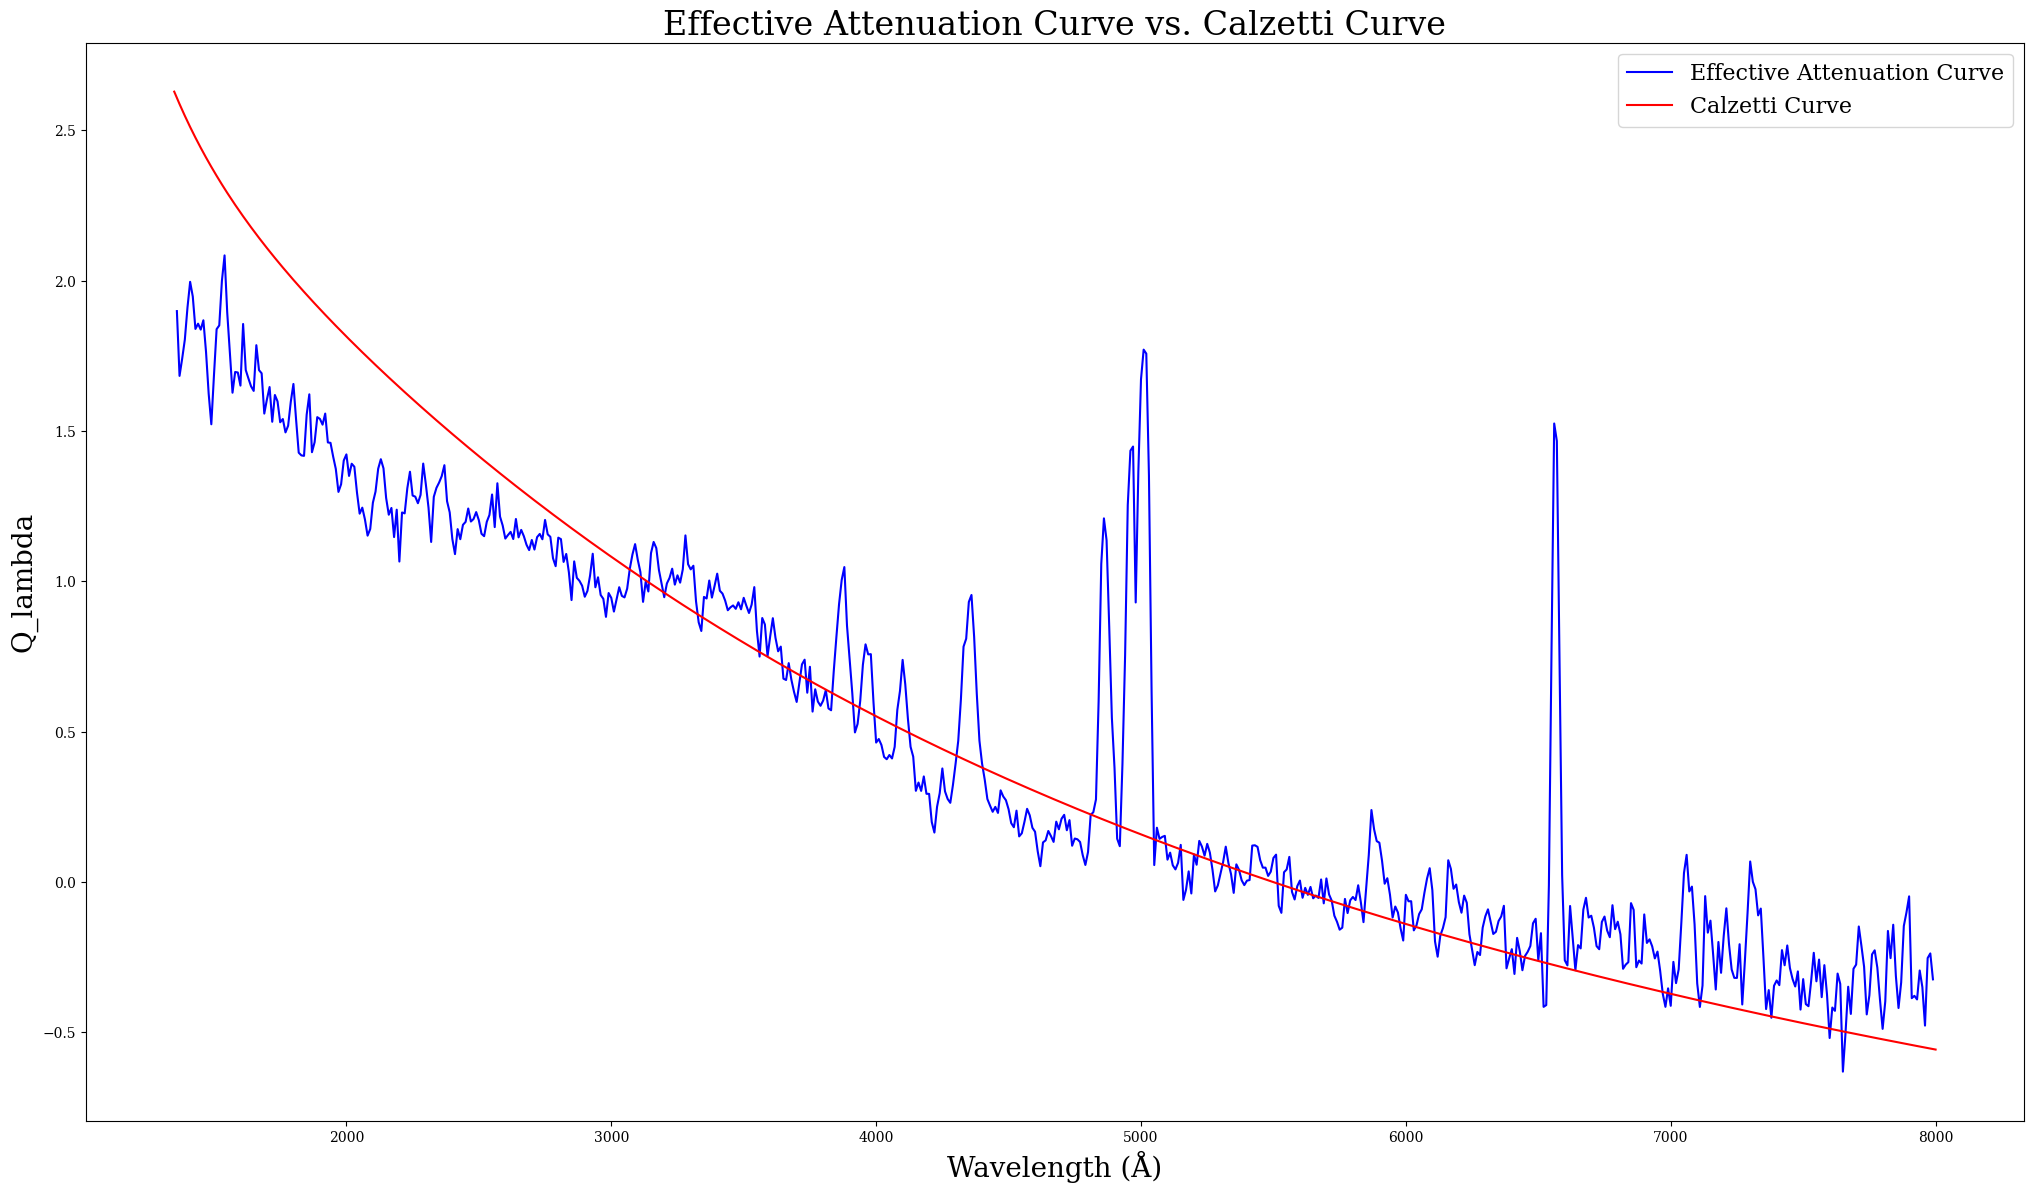

In [21]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=20)
plt.ylabel('Q_lambda', fontsize=20)
plt.title('Effective Attenuation Curve vs. Calzetti Curve', fontsize=24)
plt.legend(fontsize=16)
plt.show()

---
# in the following section. i will use the fitted 